In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Week 1. Load the Gait Dataset


*  Ensure consistent sampling frequency between left and right foot sensor data to maintain synchronization (e.g., resample, interpolation).
*  	Apply sliding window segmentation to extract meaningful gait features from long, continuous recordings (window size, overlap ratio).
*  	Normalise and standardise data to ensure consistency.




### Step 1: Link Your Google Drive
Once it's run, click on the authorisation link and sign in to your Google account.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 2: Download the Gait analysis dataset from shared Google drive





In [ ]:
from googleapiclient.discovery import build
from google.colab import auth
import os

# Google Drive API
auth.authenticate_user()
drive_service = build('drive', 'v3')

# Share folder ID
shared_folder_id = "15M28eGKosHYhWSCWtNFKLpRgHN0vaBIM"

# Local save address
destination_folder = "/content/drive/My Drive/Gait_analysis_assignment/Train_dataset"
os.makedirs(destination_folder, exist_ok=True)

def list_files_in_folder(folder_id):
    results = drive_service.files().list(
        q=f"'{folder_id}' in parents",
        fields="files(id, name, mimeType)"
    ).execute()
    return results.get('files', [])

def download_file(file_id, file_name, destination_folder):
    file_path = os.path.join(destination_folder, file_name)

    if os.path.exists(file_path):
        print(f"📂 File already exist, skip download: {file_name}")
        return

    try:
        request = drive_service.files().get_media(fileId=file_id)
        with open(file_path, 'wb') as f:
            f.write(request.execute())
        print(f"✅ Download succeed: {file_name} -> {file_path}")
    except Exception as e:
        print(f"❌ Download faild: {file_name}，error message: {e}")

def download_folder(folder_id, parent_folder):
    """Download everthing from share google drive"""
    files = list_files_in_folder(folder_id)

    for file in files:
        file_name = file['name']
        file_id = file['id']
        mime_type = file['mimeType']
        local_path = os.path.join(parent_folder, file_name)

        if mime_type == "application/vnd.google-apps.folder":
            os.makedirs(local_path, exist_ok=True)
            print(f"📂 Created folder: {local_path}")
            download_folder(file_id, local_path)
        else:
            download_file(file_id, file_name, parent_folder)

# Start downloading the entire dataset
print("🔹 Starting to download the entire dataset...")
download_folder(shared_folder_id, destination_folder)
print("✅ All files downloaded successfully, you are good to go!")


🔹 Starting to download the entire dataset...
📂 Created folder: /content/drive/My Drive/Gait_analysis_assignment/Train_dataset/Jumping
📂 File already exist, skip download: signal recording 20250121-170643-048116.csv
📂 File already exist, skip download: signal recording 20241113-162924-567180.csv
📂 File already exist, skip download: signal recording 20241113-161843-127691.csv
📂 File already exist, skip download: signal recording 20250204-154711-948616.csv
📂 File already exist, skip download: signal recording 20241113-163650-102477.csv
📂 File already exist, skip download: signal recording 20241113-161537-358325.csv
📂 File already exist, skip download: signal recording 20250121-172202-816190.csv
📂 File already exist, skip download: signal recording 20241113-163324-488026.csv
📂 File already exist, skip download: signal recording 20241113-162611-238428.csv
📂 File already exist, skip download: signal recording 20250121-171646-558932.csv
📂 File already exist, skip download: signal recording 20

### Step 3: Load the data input numpy array

In [ ]:
import pandas as pd
import os
import numpy as np
from tqdm import tqdm

def get_frame_rate(data):
    avg_interval = data['timestamp'].diff().mean()
    current_fps = 1 / avg_interval if avg_interval > 0 else None
    return current_fps


def downsample_to_60Hz(data, target_fps=60):
    total_time = data['timestamp'].iloc[-1] - data['timestamp'].iloc[0]
    total_frames = len(data)
    current_fps = total_frames / total_time if total_time > 0 else None

    if current_fps and current_fps > target_fps:
        target_frame_count = int(total_time * target_fps)

        indices = np.linspace(0, total_frames - 1, target_frame_count, dtype=int)
        data_downsampled = data.iloc[indices].reset_index(drop=True)
        return data_downsampled
    else:
        return data


def upsample_to_60Hz(data, target_fps=60):
    target_interval = 1.0 / target_fps

    new_timestamps = np.arange(data['timestamp'].min(), data['timestamp'].max(), target_interval)
    data_interpolated = data.set_index('timestamp').reindex(new_timestamps).interpolate(method='linear').reset_index()
    data_interpolated.rename(columns={'index': 'timestamp'}, inplace=True)

    return data_interpolated

def insole_process(file_path):
    target_fps = 60 # a fixed 60hz sampling frequency for all the datas
    data = pd.read_csv(file_path)
    data = data.dropna()
    left_foot_data = data[data['ele_36'] == 1]  # Left foot data
    right_foot_data = data[data['ele_36'] == 0]  # right foot data

    cols_to_extract = ['ele_' + str(i) for i in range(18)] + ['ele_18', 'ele_19', 'ele_20', 'ele_22', 'ele_23', 'ele_24'] # 0-17 Pressure + 3 axis Gyro + 3 axis acc

    left_foot_data = left_foot_data[['timestamp'] + cols_to_extract]
    right_foot_data = right_foot_data[['timestamp'] + cols_to_extract]

    left_fps = get_frame_rate(left_foot_data)
    right_fps = get_frame_rate(right_foot_data)

    # print('Left foot data', left_foot_data.shape, 'Frame rate: {:.2f} Hz'.format(left_fps))
    # print('Right foot data', right_foot_data.shape, 'Frame rate: {:.2f} Hz'.format(right_fps))

    # use low fps data to match high fps data
    if left_fps < right_fps:
        base_data = left_foot_data  # low fps data
        high_fps_data = right_foot_data  # high fps data
        suffixes = ('_left', '_right')
    else:
        base_data = right_foot_data
        high_fps_data = left_foot_data
        suffixes = ('_right', '_left')

    merged_data = pd.merge_asof(base_data.drop_duplicates(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True),
                                high_fps_data.drop_duplicates(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True),
                                on='timestamp',
                                direction='nearest',  # match nearest one
                                suffixes=suffixes,
                                tolerance=0.02) # 10ms = 0.01s

    right_first = any(col.endswith('_right') for col in merged_data.columns[1:])  # if right at front
    if right_first:
        left_columns = [col for col in merged_data.columns if '_left' in col]
        right_columns = [col for col in merged_data.columns if '_right' in col]
        merged_data = merged_data[['timestamp'] + left_columns + right_columns]  # change sequence

    merged_data = merged_data.dropna()
    current_fps = get_frame_rate(merged_data)

    if current_fps < target_fps:
        output_data = upsample_to_60Hz(merged_data, target_fps)
    elif current_fps > target_fps:
        output_data = downsample_to_60Hz(merged_data, target_fps)
    else:
        output_data = merged_data
    return output_data


In [ ]:
#  you can change window size and overlap ratio (stride/window_size) here.
window_size=20 # 0.33 second window
stride=15

# You can select features here by disabling indexing.
feature_columns = [
    # Left foot data in merged file
    'ele_0_left', 'ele_1_left', 'ele_2_left','ele_3_left', 'ele_4_left', 'ele_5_left','ele_6_left', 'ele_7_left', 'ele_8_left', 'ele_9_left', 'ele_10_left', 'ele_11_left', #Pressure
    'ele_12_left', 'ele_13_left', 'ele_14_left','ele_15_left', 'ele_16_left', 'ele_17_left', #Pressure
    'ele_18_left', 'ele_19_left', 'ele_20_left',#Acc
    'ele_22_left', #Roll
    'ele_23_left', #Pitch
    'ele_24_left', #Yaw

    # Right foot data in merged file
    'ele_0_right', 'ele_1_right', 'ele_2_right','ele_3_right', 'ele_4_right', 'ele_5_right','ele_6_right', 'ele_7_right', 'ele_8_right', 'ele_9_right', 'ele_10_right', 'ele_11_right',#Pressure
    'ele_12_right', 'ele_13_right', 'ele_14_right','ele_15_right', 'ele_16_right', 'ele_17_right',#Pressure
    'ele_18_right', 'ele_19_right', 'ele_20_right',#Acc
    'ele_22_right', #Roll
    'ele_23_right', #Pitch
    'ele_24_right' #Yaw
]

feature_size = len(feature_columns)
label_mapping = {"Normal_walking": 0,
                  "Injury_walking": 1,
                  "Stepping":2,
                  "Swaying":3,
                  "Jumping": 4,
                  }
all_features = []
all_labels = []

file_path = "/content/drive/My Drive/Gait_analysis_assignment/Train_dataset"

if not os.path.isdir(file_path):
    print(f"Error: {file_path} is not a directory or does not exist, double check the above file path!")


for folder_name in os.listdir(file_path):
    folder_path = os.path.join(file_path, folder_name)

    for keyword in tqdm(label_mapping, desc="Processing data", unit= folder_name):
        if keyword in folder_name:
            for file_name in os.listdir(folder_path):
                if file_name.endswith(".csv"):
                    csv_file_path = os.path.join(folder_path, file_name)
                    # print("Processing",csv_file_path)
                    features = insole_process(csv_file_path)[feature_columns]

                    num_frames = features.shape[0]
                    for start_idx in range(0, num_frames - window_size + 1, stride):
                      end_idx = start_idx + window_size
                      window_features = features[start_idx:end_idx]

                      all_features.append(window_features)
                      all_labels.append(label_mapping[keyword])

all_features = np.array(all_features)
all_labels = np.array(all_labels)

print("="*50)
print("✅ Data Processing Completed Successfully!")
print(f"📊 Total Dataset Samples: {all_features.shape[0]}")
print(f"📏 Window Size: {window_size} frames ({window_size / 60:.2f} seconds)")
print(f"🔄 Overlap ratio: {stride/window_size:.2f}")
print(f"🧩 Feature Shape {all_features.shape}")
print(f"🔢 Number of Labels: {all_labels.shape[0]}")

Processing data: 100%|██████████| 5/5 [00:09<00:00,  1.84s/Stepping]


✅ Data Processing Completed Successfully!
📊 Total Dataset Samples: 19811
📏 Window Size: 20 frames (0.33 seconds)
🔄 Overlap ratio: 0.75
🧩 Feature Shape (19811, 20, 48)
🔢 Number of Labels: 19811


## Week 2 Model Design and Parameter Tuning
In this phase, you will focus on designing the deep learning model for time-series gait classification and optimizing its performance through hyperparameter tuning. The goal is to improve model accuracy, stability, and generalization by systematically adjusting key training parameters.

*  Experiment with different parameters to fine-tune the model’s performance.
*  	Use the validation results to guide your parameter choices.




### Step 1 Let's Load Our Gait Dataset From Week 1

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Define the dataset class for gait analysis
class GaitDataset(Dataset):
    def __init__(self, features, labels, Standard_flag=False, Normalize_flag=False):
        """
        Initialize the dataset with feature and label tensors.

        :param features: NumPy array of shape (num_samples, window_size, num_features)
        :param labels: NumPy array of shape (num_samples,)
        """
        num_samples, window_size, num_features = features.shape
        reshaped_features = features.reshape(-1, num_features)  # Flatten the window axis

        if Standard_flag:
            scaler = StandardScaler()

            # Fit the scaler and transform the data (normalize)
            Processed_features = scaler.fit_transform(reshaped_features)

            # Reshape back to the original dimensions (num_samples, window_size, num_features)
            features = Processed_features.reshape((num_samples, window_size, num_features))

        if Normalize_flag:
            scaler = MinMaxScaler()

            # Fit the scaler and transform the data (normalize)
            Processed_features = scaler.fit_transform(reshaped_features)

            # Reshape back to the original dimensions (num_samples, window_size, num_features)
            features = Processed_features.reshape((num_samples, window_size, num_features))

        self.features = torch.tensor(features, dtype=torch.float32)  # Convert features to a PyTorch tensor (float32)
        self.labels = torch.tensor(labels, dtype=torch.long)  # Convert labels to a PyTorch tensor (long, for classification)

    def __len__(self):
        """
        Return the total number of samples in the dataset.
        """
        return len(self.features)

    def __getitem__(self, idx):
        """
        Retrieve a single sample (features, label) by index.
        :param idx: Index of the sample to retrieve
        :return: Tuple (features, label)
        """
        return self.features[idx], self.labels[idx]

# Convert NumPy arrays into a PyTorch dataset
dataset = GaitDataset(all_features, all_labels,
                      Standard_flag = False,
                      Normalize_flag= False
                      )

train_size = int(0.8 * len(dataset))  # 80% for training
val_size = int(0.1 * len(dataset))    # 10% for validation
test_size = len(dataset) - train_size - val_size  # Remaining 10% for testing

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# ✅ Verify the dataset by printing its details
print(f"✅ Dataset loaded successfully! Total samples: {len(dataset)}")
print(f"   🔹 Training set: {len(train_dataset)} samples")
print(f"   🔹 Validation set: {len(val_dataset)} samples")
print(f"   🔹 Test set: {len(test_dataset)} samples")


✅ Dataset loaded successfully! Total samples: 19811
   🔹 Training set: 15848 samples
   🔹 Validation set: 1981 samples
   🔹 Test set: 1982 samples


### Step 2 Let's Built Some Funcations for Model Training and Validate

In [ ]:
import torch

# Function to train the model
def train(model, train_loader, criterion, optimizer):
    """
    Trains the given model using the provided training data.

    Args:
        model (torch.nn.Module): The neural network model.
        train_loader (torch.utils.data.DataLoader): DataLoader containing training data.
        criterion (torch.nn.Module): Loss function (e.g., CrossEntropyLoss).
        optimizer (torch.optim.Optimizer): Optimization algorithm (e.g., Adam, SGD).

    Returns:
        tuple: Average training loss and training accuracy (in percentage).
    """
    model.train()  # Set model to training mode
    total_loss = 0  # Initialize total loss for the epoch
    correct = 0  # Initialize count of correctly classified samples
    total = 0  # Initialize total number of samples

    for inputs, targets in train_loader:  # Iterate over training batches
        inputs, targets = inputs.to(device), targets.to(device)  # Move data to the GPU or CPU
        optimizer.zero_grad()  # Clear previous gradients

        outputs = model(inputs)  # Forward pass: compute predictions
        loss = criterion(outputs, targets)  # Compute loss

        loss.backward()  # Backward pass: compute gradients
        optimizer.step()  # Update model weights

        total_loss += loss.item()  # Accumulate batch loss
        _, predicted = torch.max(outputs, 1)  # Get predicted class indices
        correct += (predicted == targets).sum().item()  # Count correct predictions
        total += targets.size(0)  # Count total samples

    accuracy = 100 * correct / total  # Compute accuracy as percentage
    return total_loss / len(train_loader), accuracy  # Return average loss and accuracy


# Function to validate the model
def validate(model, val_loader, criterion):
    """
    Evaluates the model performance on the validation dataset.

    Args:
        model (torch.nn.Module): The neural network model.
        val_loader (torch.utils.data.DataLoader): DataLoader containing validation data.
        criterion (torch.nn.Module): Loss function (e.g., CrossEntropyLoss).

    Returns:
        tuple: Average validation loss and validation accuracy (in percentage).
    """
    model.eval()  # Set model to evaluation mode
    total_loss = 0  # Initialize total validation loss
    correct = 0  # Initialize count of correctly classified samples
    total = 0  # Initialize total number of samples

    with torch.no_grad():  # Disable gradient computation for efficiency
        for inputs, targets in val_loader:  # Iterate over validation batches
            inputs, targets = inputs.to(device), targets.to(device)  # Move data to the GPU or CPU

            outputs = model(inputs)  # Forward pass: compute predictions
            loss = criterion(outputs, targets)  # Compute loss

            total_loss += loss.item()  # Accumulate batch loss
            _, predicted = torch.max(outputs, 1)  # Get predicted class indices
            correct += (predicted == targets).sum().item()  # Count correct predictions
            total += targets.size(0)  # Count total samples

    accuracy = 100 * correct / total  # Compute accuracy as percentage
    return total_loss / len(val_loader), accuracy  # Return average loss and accuracy


### Step 3 let's design our first ML model:

In [ ]:
import torch
import torch.nn as nn

# define your first model.  Note: you can change to any neuro network you want here is only a demo
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.reshape(x.size(0), -1) # Flatten the input tensor before passing it through the fully connected layers.
        x = torch.relu(self.fc1(x))
        # x = torch.relu(self.fc2(x))
        # x = self.fc3(x)
        return x

# Declare model parameters
my_ml_model = MLP(input_dim = window_size * feature_size,  # Input dimension is the number of features in each window (window_size * feature_size)
                  hidden_dim = 8,  # Number of neurons in the hidden layers (can be tuned for better performance)
                  output_dim = 5)   # Output dimension is 5, corresponding to the number of classes for classification (e.g., 5 different gait patterns)

### Step 5 Summary the model

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

# Print model summary
batch_size=32
print(summary(my_ml_model, input_size=(batch_size, window_size * feature_size)))

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [32, 5]                   --
├─Linear: 1-1                            [32, 8]                   7,688
├─Linear: 1-2                            [32, 8]                   72
├─Linear: 1-3                            [32, 5]                   45
Total params: 7,805
Trainable params: 7,805
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.25
Input size (MB): 0.12
Forward/backward pass size (MB): 0.01
Params size (MB): 0.03
Estimated Total Size (MB): 0.16


### Step 6 Train the model
Here's how to use the `train` method for parameter tuning on your dataset for 20 epochs with an Adam optimiser.

In [ ]:
import torch.optim as optim
import random

save_file_path = "/content/drive/My Drive/Gait_analysis_assignment/Saved_model/"
os.makedirs(save_file_path, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set a fixed random seed to ensure reproducibility in model training
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# create DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# CrossEntropyLoss with optimizer, and think is there anything more you can add
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(my_ml_model.parameters(), lr=0.0001)

model = my_ml_model.to(device)

# Initialize lists to store the losses and accuracies for plotting
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# main training loop
num_epochs = 20 # you will need to change that
for epoch in range(num_epochs):
    train_loss, train_accuracy = train(model, train_loader, criterion, optimizer)
    val_loss, val_accuracy = validate(model, val_loader, criterion)

    # Store the results for plotting
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch + 1}/{num_epochs}], ")
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, ")
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

# Save the model after training
model_save_path = os.path.join(save_file_path, "gait_model.pth")
torch.save(model, model_save_path)
print(f"Model saved to {model_save_path}")


Using device: cuda
Epoch [1/20], 
Train Loss: 1.6104, Train Accuracy: 28.19%, 
Val Loss: 1.1372, Val Accuracy: 50.38%
Epoch [2/20], 
Train Loss: 1.1233, Train Accuracy: 50.04%, 
Val Loss: 1.1229, Val Accuracy: 50.33%
Epoch [3/20], 
Train Loss: 1.1132, Train Accuracy: 50.09%, 
Val Loss: 1.1140, Val Accuracy: 50.38%
Epoch [4/20], 
Train Loss: 1.1043, Train Accuracy: 50.08%, 
Val Loss: 1.1064, Val Accuracy: 50.43%
Epoch [5/20], 
Train Loss: 1.0969, Train Accuracy: 50.11%, 
Val Loss: 1.0991, Val Accuracy: 50.38%
Epoch [6/20], 
Train Loss: 1.0897, Train Accuracy: 50.09%, 
Val Loss: 1.0927, Val Accuracy: 50.38%
Epoch [7/20], 
Train Loss: 1.0838, Train Accuracy: 50.11%, 
Val Loss: 1.0863, Val Accuracy: 50.43%
Epoch [8/20], 
Train Loss: 1.1343, Train Accuracy: 48.69%, 
Val Loss: 1.0812, Val Accuracy: 50.43%
Epoch [9/20], 
Train Loss: 1.0739, Train Accuracy: 50.11%, 
Val Loss: 1.0763, Val Accuracy: 50.43%
Epoch [10/20], 
Train Loss: 1.0702, Train Accuracy: 50.11%, 
Val Loss: 1.0718, Val Accurac

## Week3 Train and Evaluate Machine Learning Models

### Step 1 Plot the Train Result From Week 2
What differences did you observe in the curves by constantly adjusting the parameters? Think about how to find the optimal set of parameters.

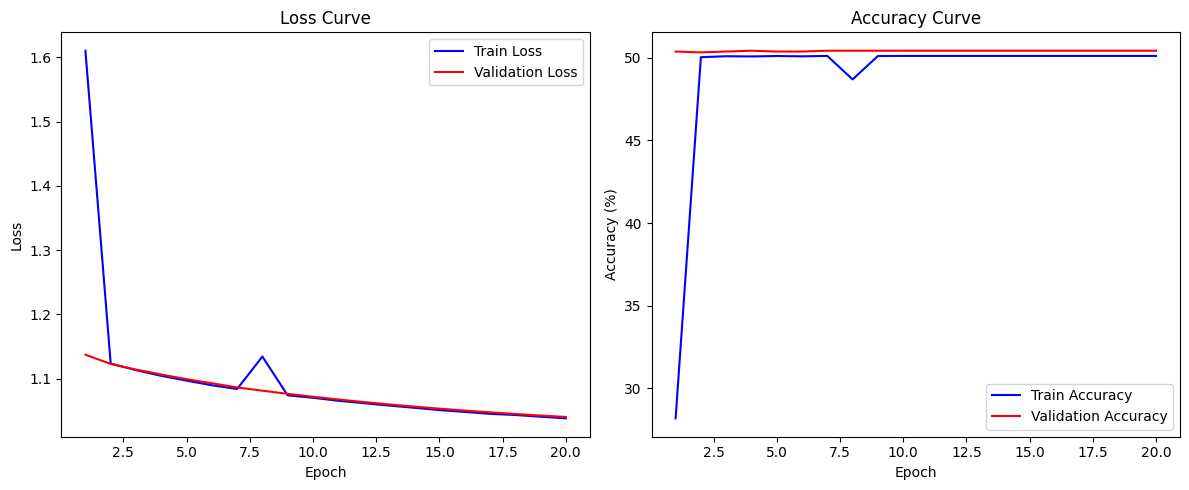

In [ ]:
import matplotlib.pyplot as plt

# After training is done, plot the loss and accuracy curves
# Plotting Loss Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)  # Plot the loss curve
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='red')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy Curves
plt.subplot(1, 2, 2)  # Plot the accuracy curve
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy', color='blue')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy', color='red')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

### Step 2 Let's Test Our model

Once you've trained N iterations, you will be able to see which set of hyperparameter performed the best.

In [ ]:
def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == targets).sum().item()
            total += targets.size(0)

    accuracy = 100 * correct / total
    return accuracy


In [ ]:
import torch

# Select device: Use GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the path where the trained model is saved
model_save_path = "/content/drive/MyDrive/Gait_analysis_assignment/Saved_model/gait_model.pth"

# Recreate the model architecture (Make sure it matches the saved model)
model = MLP(input_dim=window_size * feature_size, hidden_dim=8, output_dim=5)

# Load the trained model
# 'weights_only=False' ensures that we are loading the entire model (structure + weights)
model = torch.load(model_save_path, map_location=device, weights_only=False)

# Move the model to the selected device (GPU or CPU)
model.to(device)

# Evaluate the model on the test dataset
test_accuracy = test(model, test_loader)

# Print a detailed summary of the test results
print("=" * 50)
print("✅ Model Testing Completed!")
print(f"📌 Model Path: {model_save_path}")
print(f"📊 Test Dataset Accuracy: {test_accuracy:.2f}%")
print("📌 Device Used:", device)
print("=" * 50)

✅ Model Testing Completed!
📌 Model Path: /content/drive/MyDrive/Gait_analysis_assignment/Saved_model/gait_model.pth
📊 Test Dataset Accuracy: 51.16%
📌 Device Used: cuda


### Step 3 Plot Confusion Matrix
*   precision    
*   recall  
*   f1-score



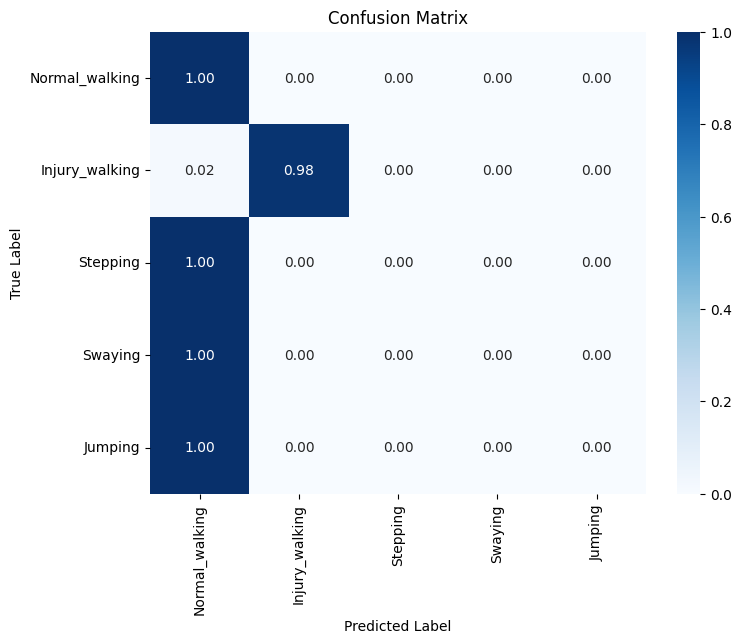

Classification Report:
                 precision    recall  f1-score   support

Normal_walking       0.31      1.00      0.47       430
Injury_walking       1.00      0.98      0.99       594
      Stepping       0.00      0.00      0.00       274
       Swaying       0.00      0.00      0.00       358
       Jumping       0.00      0.00      0.00       326

      accuracy                           0.51      1982
     macro avg       0.26      0.40      0.29      1982
  weighted avg       0.37      0.51      0.40      1982



In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(model, test_loader, class_names):
    """
    Generates and plots a confusion matrix for the given model on the test dataset.

    :param model: Trained PyTorch model
    :param test_loader: DataLoader for test dataset
    :param class_names: List of class names for labeling the confusion matrix
    """
    model.eval()  # Set model to evaluation mode

    all_preds = []
    all_test_labels = []

    # Disable gradient calculation for efficiency
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())  # Store predictions
            all_test_labels.extend(labels.cpu().numpy())  # Store true labels

    # Compute the confusion matrix
    cm = confusion_matrix(all_test_labels, all_preds)

    # Normalize confusion matrix (convert to percentage)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot the confusion matrix using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    # Print classification report
    print("Classification Report:\n", classification_report(all_test_labels, all_preds, target_names=class_names, zero_division=0))

# Define class names (modify based on your dataset)
class_names = ["Normal_walking", "Injury_walking", "Stepping", "Swaying", "Jumping"]

# Call the function to plot the confusion matrix
plot_confusion_matrix(model, test_loader, class_names)


### Step 4 If the result doesn't look good, consider adjusting the following parameters:

*   Learning Rate:
    Adjust the learning rate to see if it helps the model converge faster or avoid overshooting the optimal solution.

*   Batch Size:
    Experiment with different batch sizes. A smaller batch size may provide a more stable gradient but may take longer to train.

*   Model Architecture:
    Modify the number of layers and units (neurons) in each layer of your neural network to better capture the patterns in the data.
    Example: Increase hidden_dim or add more layers.

*   Activation Functions:
    Try different activation functions, such as ReLU, LeakyReLU, Tanh, or Sigmoid.
    Example: x = torch.relu(self.fc1(x)) or use x = torch.sigmoid(self.fc1(x)).

*   Epochs:
    Increase or decrease the number of epochs to see if the model can better converge.
    Example: num_epochs = 50

*  Window Size and stride:
    The window size and stride are particularly important for time series data. The window size determines how much historical data is used in each window, and the stride controls how much the window moves forward each time. Larger window sizes may capture more complex patterns, but they may also introduce more noise.

*  Normalization or Standardize:
    Apply MinMax scaling or Standardization (mean=0, std=1) for better convergence during training. By turn the flag on in dataset funcation.
